# 01 · Data Loading & Exploratory Data Analysis

**Project:** Football Player Transfer Market Value Prediction
**Dataset:** [Player Scores (Transfermarkt)](https://www.kaggle.com/datasets/davidcariboo/player-scores) by David Cariboo

This notebook:
1. Loads the raw Kaggle CSV files
2. Builds the **target variable** — each player's current market value
3. Explores the data (missing values, distributions, relationships)
4. Saves a cleaned `players_master.csv` for the next notebook

> **Before running:** download the dataset from Kaggle and place the CSV files in `../data/raw/`.
> Required files: `players.csv`, `player_valuations.csv`, `clubs.csv`, `competitions.csv`
> (also used later: `appearances.csv`, `transfers.csv`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)


## 1. Load raw data

In [2]:
required_files = ["players.csv", "player_valuations.csv", "clubs.csv", "competitions.csv"]
missing = [f for f in required_files if not (RAW / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing files in {RAW.resolve()}: {missing}\n"
        "Download the dataset from https://www.kaggle.com/datasets/davidcariboo/player-scores "
        "and place the CSVs in data/raw/"
    )

players = pd.read_csv(RAW / "players.csv")
valuations = pd.read_csv(RAW / "player_valuations.csv")
clubs = pd.read_csv(RAW / "clubs.csv")
competitions = pd.read_csv(RAW / "competitions.csv")

# Parse dates (column names are consistent across dataset versions)
players["date_of_birth"] = pd.to_datetime(players["date_of_birth"], errors="coerce")
if "contract_expiration_date" in players.columns:
    players["contract_expiration_date"] = pd.to_datetime(players["contract_expiration_date"], errors="coerce")
valuations["date"] = pd.to_datetime(valuations["date"], errors="coerce")

print("players:      ", players.shape)
print("valuations:   ", valuations.shape)
print("clubs:        ", clubs.shape)
print("competitions: ", competitions.shape)
players.head()


players:       (50149, 26)
valuations:    (656301, 6)
clubs:         (796, 17)
competitions:  (65, 11)


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,1978-06-09,Centre-Forward,Attack,right,184.0,NaT,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,1980-08-06,Goalkeeper,Goalkeeper,left,190.0,NaT,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,1981-01-30,Centre-Forward,Attack,NaN,NaN,NaT,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,1978-05-08,Centre-Back,Defender,NaN,NaN,NaT,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus FC,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,1981-03-18,Goalkeeper,Goalkeeper,right,194.0,NaT,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,Bayern Munich,100000.0,3000000.0


## 2. Build the target: current market value\n\n`players.csv` has a `market_value_in_eur` snapshot, but `player_valuations.csv` has the full history. We take each player's **most recent valuation** as the current market value (target).

In [3]:
latest_val = (
    valuations.sort_values("date")
    .groupby("player_id", as_index=False)
    .last()[["player_id", "date", "market_value_in_eur"]]
    .rename(columns={"date": "valuation_date", "market_value_in_eur": "current_market_value_eur"})
)
print(f"Players with at least one valuation: {latest_val.shape[0]:,}")
latest_val.head()


Players with at least one valuation: 41,528


,player_id,valuation_date,current_market_value_eur
0,10,2016-01-04,1000000
1,26,2017-12-28,750000
2,65,2016-06-21,1000000
3,77,2016-11-15,200000
4,80,2018-06-05,100000


In [4]:
master = players.merge(latest_val, on="player_id", how="inner")
master = master.merge(
    clubs.add_prefix("club_"),
    left_on="current_club_id", right_on="club_club_id", how="left"
)
print("Master table:", master.shape)
master.head()


Master table: (41528, 45)


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur,valuation_date,current_market_value_eur,club_club_id,club_club_code,club_name,club_domestic_competition_id,club_total_market_value,club_squad_size,club_average_age,club_foreigners_number,club_foreigners_percentage,club_national_team_players,club_stadium_name,club_stadium_seats,club_net_transfer_record,club_coach_name,club_last_season,club_filename,club_url
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,1978-06-09,Centre-Forward,Attack,right,184.0,NaT,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0,2016-01-04,1000000,398.0,lazio-rom,Società Sportiva Lazio S.p.A.,IT1,NaN,28.0,27.8,17.0,60.7,11.0,Olimpico di Roma,70634.0,+€13.55m,NaN,2025.0,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/lazio-rom/star...
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,1980-08-06,Goalkeeper,Goalkeeper,left,190.0,NaT,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0,2017-12-28,750000,16.0,borussia-dortmund,Borussia Dortmund,L1,NaN,29.0,24.8,16.0,55.2,15.0,SIGNAL IDUNA PARK,81365.0,€-19.50m,Niko Kovac,2025.0,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/borussia-dortm...
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,1981-01-30,Centre-Forward,Attack,NaN,NaN,NaT,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0,2016-06-21,1000000,1091.0,paok-thessaloniki,Panthessalonikios Athlitikos Omilos Konstantin...,GR1,NaN,31.0,28.0,18.0,58.1,10.0,Toumba Stadium,28703.0,€-9.80m,NaN,2025.0,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/paok-thessalon...
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,1978-05-08,Centre-Back,Defender,NaN,NaN,NaT,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus FC,200000.0,24500000.0,2016-11-15,200000,506.0,juventus-turin,Juventus FC,IT1,NaN,29.0,27.2,20.0,69.0,17.0,Allianz Stadium,41507.0,€-47.05m,Igor Tudor,2025.0,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/juventus-turin...
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,1981-03-18,Goalkeeper,Goalkeeper,right,194.0,NaT,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,Bayern Munich,100000.0,3000000.0,2018-06-05,100000,27.0,fc-bayern-munchen,Bayern Munich,L1,NaN,31.0,26.1,15.0,48.4,20.0,Allianz Arena,75000.0,€-81.25m,Vincent Kompany,2025.0,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/fc-bayern-munc...


## 3. Missing values

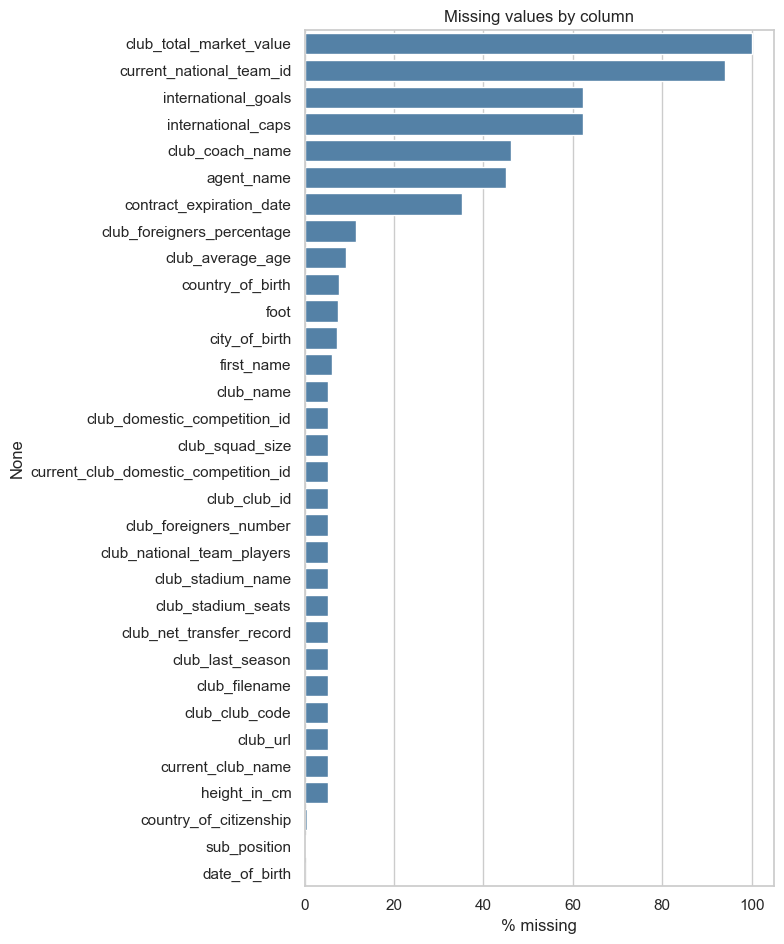

In [5]:
missing_pct = master.isna().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
plt.figure(figsize=(8, max(3, len(missing_pct) * 0.3)))
sns.barplot(x=missing_pct.values * 100, y=missing_pct.index, color="steelblue")
plt.xlabel("% missing")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()


## 4. Target distribution\n\nMarket values are heavily right-skewed (a handful of superstar players are worth far more than everyone else), so we look at both raw and log-scaled distributions. We'll model on the **log-transformed** target later.

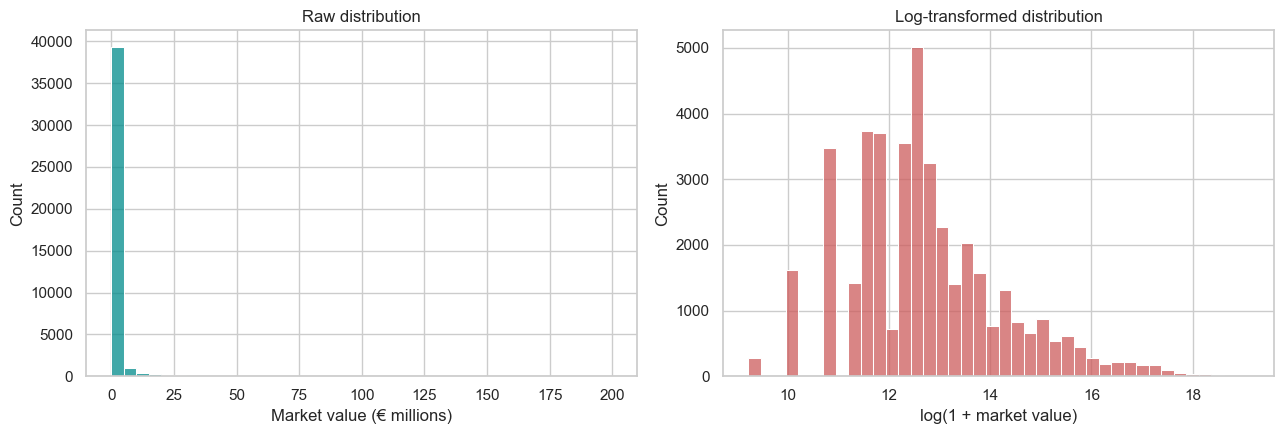

count         41,528
mean       1,511,049
std        5,854,556
min           10,000
25%          100,000
50%          275,000
75%          700,000
max      200,000,000
Name: current_market_value_eur, dtype: str

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(master["current_market_value_eur"] / 1e6, bins=40, ax=axes[0], color="darkcyan")
axes[0].set_xlabel("Market value (€ millions)")
axes[0].set_title("Raw distribution")

sns.histplot(np.log1p(master["current_market_value_eur"]), bins=40, ax=axes[1], color="indianred")
axes[1].set_xlabel("log(1 + market value)")
axes[1].set_title("Log-transformed distribution")

plt.tight_layout()
plt.show()

master["current_market_value_eur"].describe().apply(lambda x: f"{x:,.0f}")


## 5. Market value vs. age

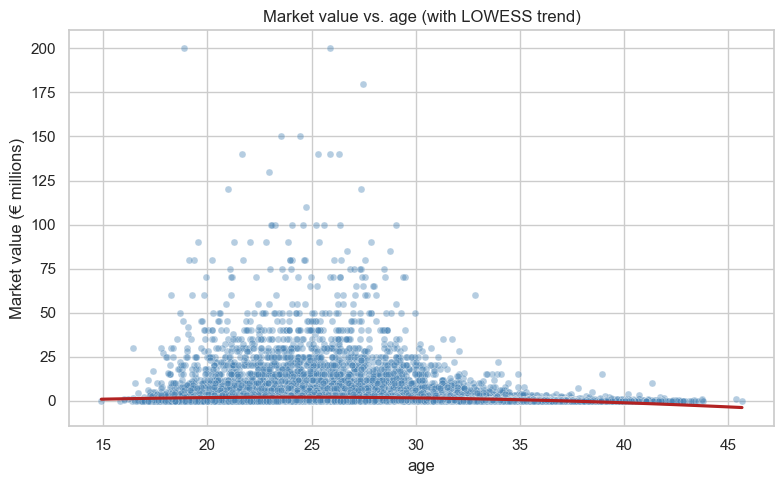

In [7]:
master["age"] = (master["valuation_date"] - master["date_of_birth"]).dt.days / 365.25

plt.figure(figsize=(8, 5))
sns.scatterplot(data=master, x="age", y=master["current_market_value_eur"] / 1e6,
                 alpha=0.4, s=25, color="steelblue")
sns.regplot(data=master, x="age", y=master["current_market_value_eur"] / 1e6,
            scatter=False, order=2, color="firebrick")
plt.ylabel("Market value (€ millions)")
plt.title("Market value vs. age (with LOWESS trend)")
plt.tight_layout()
plt.show()


## 6. Market value by position

/var/folders/pp/m3hnlq2111vgldrdsnx01j2r0000gn/T/ipykernel_18819/1526481528.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master, x="position", y=np.log1p(master["current_market_value_eur"]),


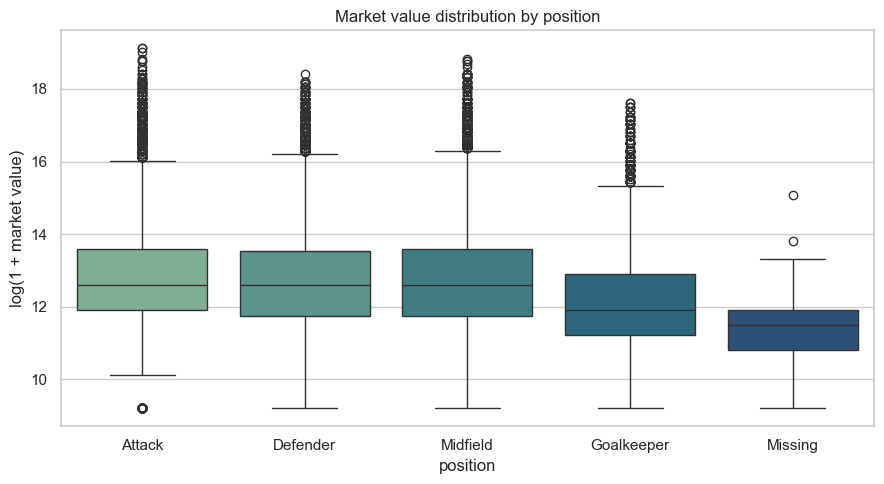

In [8]:
if "position" in master.columns:
    order = (master.groupby("position")["current_market_value_eur"]
             .median().sort_values(ascending=False).index)
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=master, x="position", y=np.log1p(master["current_market_value_eur"]),
                order=order, palette="crest")
    plt.ylabel("log(1 + market value)")
    plt.title("Market value distribution by position")
    plt.tight_layout()
    plt.show()


## 7. Correlation between numeric features

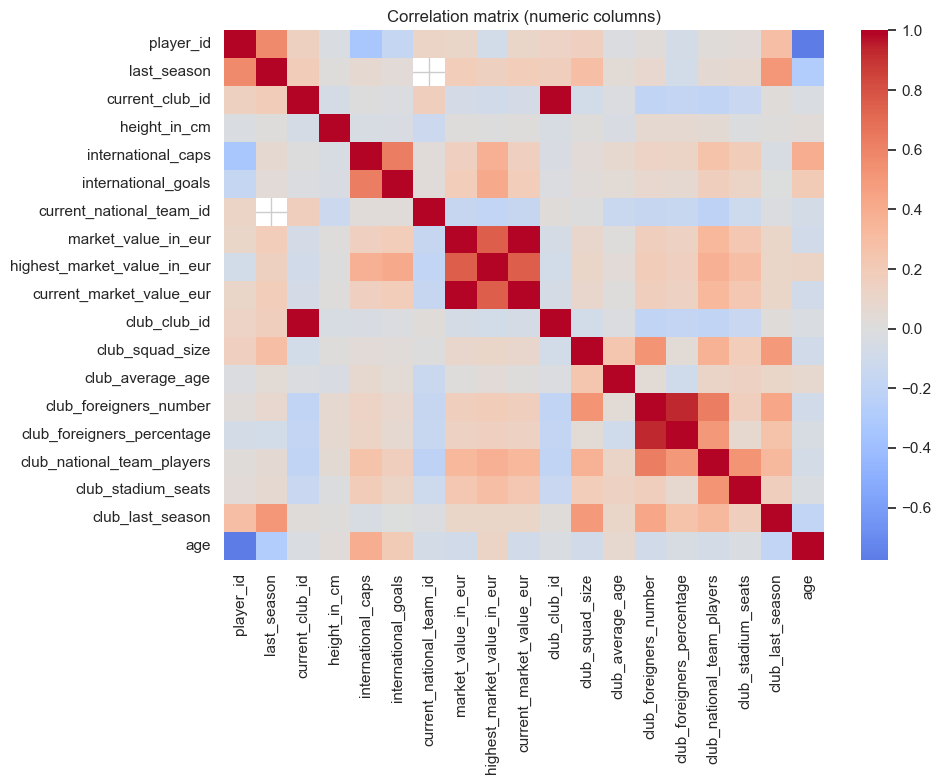

In [9]:
numeric_cols = master.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if master[c].nunique() > 1][:20]  # keep it readable

plt.figure(figsize=(10, 8))
sns.heatmap(master[numeric_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout()
plt.show()


## 8. Top 15 most valuable players (current snapshot)

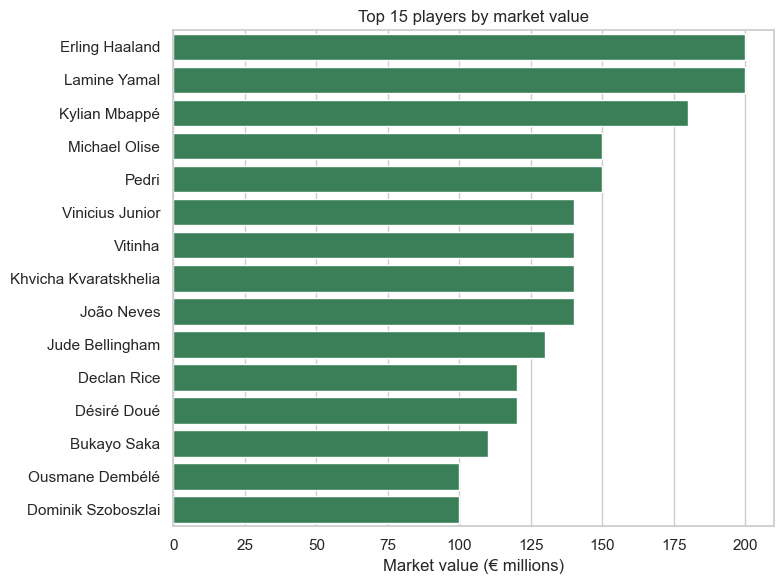

In [10]:
top15 = master.nlargest(15, "current_market_value_eur")[["name", "position", "age", "current_market_value_eur"]]
plt.figure(figsize=(8, 6))
sns.barplot(data=top15, y="name", x=top15["current_market_value_eur"] / 1e6, color="seagreen")
plt.xlabel("Market value (€ millions)")
plt.ylabel("")
plt.title("Top 15 players by market value")
plt.tight_layout()
plt.show()


## 9. Save cleaned table for feature engineering

In [11]:
out_path = PROCESSED / "players_master.csv"
master.to_csv(out_path, index=False)
print(f"Saved {master.shape[0]:,} rows x {master.shape[1]} cols -> {out_path}")


Saved 41,528 rows x 46 cols -> ../data/processed/players_master.csv
